In [1]:

import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

In [2]:
# 1 PATHS
#train_dir = ""
#test_dir = ""
dataset_path = "/content/drive/MyDrive/archive (3)"

full_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)


Found 3019 files belonging to 2 classes.


In [3]:
train_dir = "/content/drive/MyDrive/archive (3)/train"
test_dir = "/content/drive/MyDrive/archive (3)/test"

img_size = (224, 224)
batch_size = 32


In [4]:
import tensorflow as tf
from tensorflow.keras import layers

# Data Augmentation Pipeline
#Data se le kar final prediction tak ka poora process augmentation
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal_and_vertical"),

    layers.RandomRotation(0.2),

    layers.RandomZoom(0.2),

    layers.RandomContrast(0.2),

    layers.RandomTranslation(0.1, 0.1),

    layers.RandomBrightness(0.2),

])

In [5]:


#Data Augmentation
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [6]:
#test data
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

In [7]:

#  LOAD DATA
# Load TRAIN data (80%)
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

# Load VALIDATION data (20%)
val_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

# Load TEST data (completely separate)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 1042 images belonging to 1 classes.
Found 260 images belonging to 1 classes.
Found 1717 images belonging to 2 classes.


In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping

In [9]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,      # remove original output layer
    weights='imagenet'
)

# Freeze pretrained layers
base_model.trainable = False

# Build New Model
model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dropout(0.3),

    Dense(train_data.num_classes, activation='softmax')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# EARLY STOPPING

early_stop = EarlyStopping(
    patience=3,
    restore_best_weights=True
)

# TRAIN MODEL

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


33/33 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 30s 925ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 30s 926ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 30s 912ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00


In [11]:
# Load Pretrained Base Model (ImageNet weights)
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,      # remove original output layer
    weights='imagenet'
)

# Freeze pretrained layers
base_model.trainable = False

# Build New Model
model = Sequential([
  # feature extractor
    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
  # reduce overfitting
    Dropout(0.3),

    Dense(train_data.num_classes, activation='softmax')
])


In [12]:
# COMPILE MODEL

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# EARLY STOPPING


early_stop = EarlyStopping(
    patience=3,
    restore_best_weights=True
)

# TRAIN MODEL

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/losses/losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 30s 916ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 31s 938ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 31s 920ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00


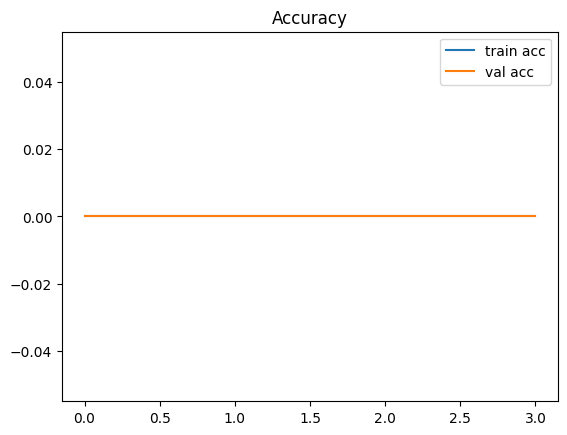

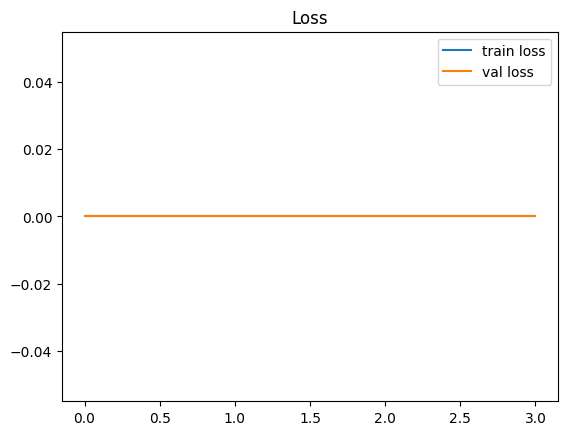

In [13]:

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss graph

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()